### Grad Cam

#### Loading in the model

In [2]:
# loading in the model
import torch
import os
import random
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = resnet18(weights=None)          # avoids any download
model.fc = nn.Linear(model.fc.in_features, 2)

state = torch.load("best_model.pth", map_location=DEVICE)
model.load_state_dict(state)
model.to(DEVICE).eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Loading in the data

In [ ]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 32  # keep consistent

def load_npz_split(split):
    data = np.load(f"data/preprocessed/{split}.npz")
    images = torch.from_numpy(data["images"]).float()
    labels = torch.from_numpy(data["labels"]).long()
    return TensorDataset(images, labels)

train_dataset = load_npz_split("train")
val_dataset   = load_npz_split("val")
test_dataset  = load_npz_split("test")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

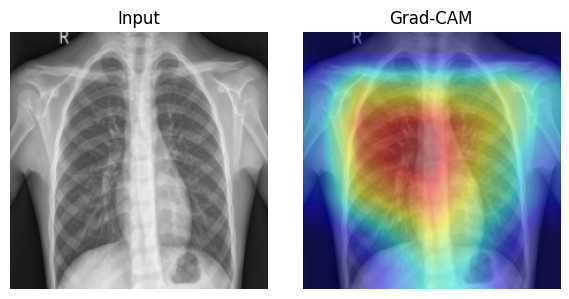

In [4]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Inverse normalization for visualization (only for display)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def denorm(img_tensor):
    mean = torch.tensor(IMAGENET_MEAN, device=img_tensor.device)[:, None, None]
    std  = torch.tensor(IMAGENET_STD,  device=img_tensor.device)[:, None, None]
    return (img_tensor * std + mean).clamp(0, 1)

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.hooks = []
        self._register_hooks()

    def _register_hooks(self):
        def fwd_hook(module, inp, out):
            self.activations = out.detach()

        def bwd_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.hooks.append(self.target_layer.register_forward_hook(fwd_hook))
        self.hooks.append(self.target_layer.register_full_backward_hook(bwd_hook))

    def remove(self):
        for h in self.hooks:
            h.remove()

    def __call__(self, x, class_idx=None):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(x)

        if class_idx is None:
            class_idx = logits.argmax(dim=1)

        # One scalar per image for backward
        loss = logits[torch.arange(logits.size(0)), class_idx].sum()
        loss.backward()

        # Global average pooling on gradients
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)
        cam = F.relu(cam)

        # Normalize each CAM to [0,1]
        cam_min = cam.view(cam.size(0), -1).min(dim=1)[0][:, None, None]
        cam_max = cam.view(cam.size(0), -1).max(dim=1)[0][:, None, None]
        cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)
        return cam

# --- Example usage on one batch sample ---
model.eval()
cam_extractor = GradCAM(model, model.layer4[-1].conv2)

# Get one batch
imgs, labels = next(iter(test_loader))
imgs = imgs.to(DEVICE)

# Compute CAMs for predicted class
cams = cam_extractor(imgs)
cam_extractor.remove()

# Visualize one example
idx = 0
img = denorm(imgs[idx]).permute(1, 2, 0).cpu().numpy()
heatmap = cams[idx].cpu().numpy()
heatmap = F.interpolate(torch.tensor(heatmap)[None, None], size=img.shape[:2], mode="bilinear", align_corners=False)[0, 0].numpy()

plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Input")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img)
plt.imshow(heatmap, cmap="jet", alpha=0.45)
plt.title("Grad-CAM")
plt.axis("off")
plt.tight_layout()
plt.show()

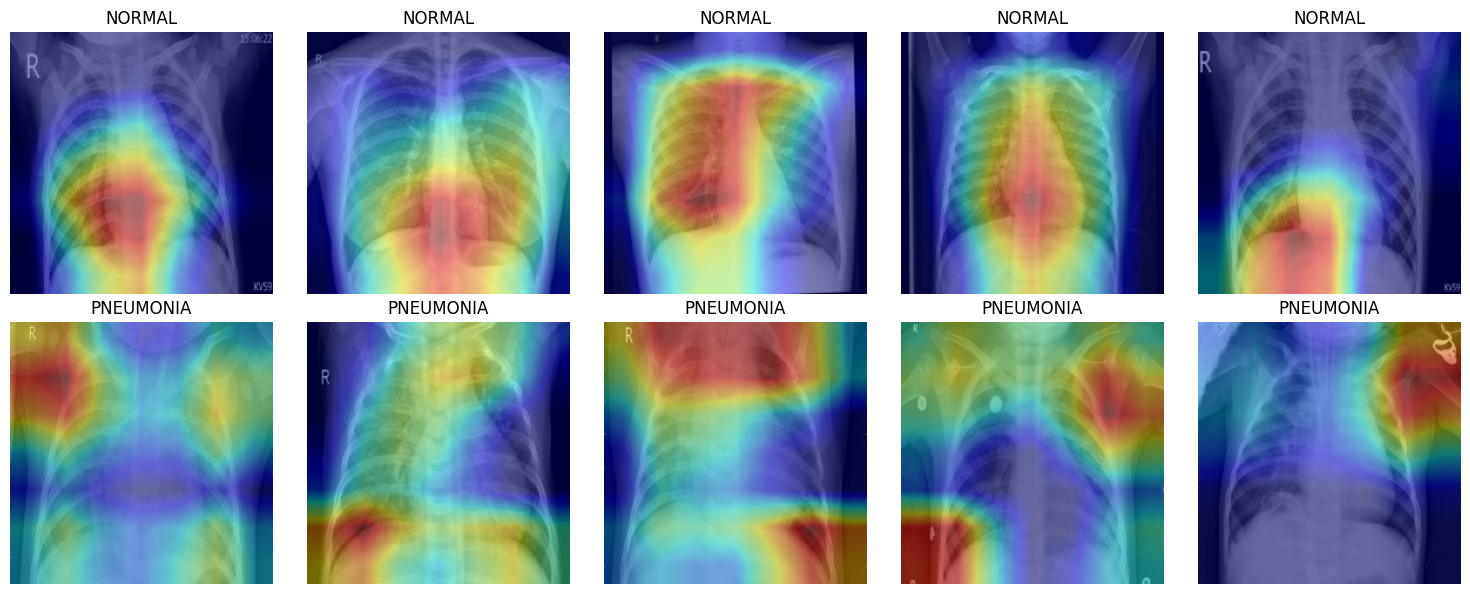

In [5]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Assumes GradCAM and denorm() are already defined above
class_names = ["NORMAL", "PNEUMONIA"]  # adjust if your label mapping differs

def sample_indices_by_class(labels, cls, n=5):
    idx = torch.where(labels == cls)[0]
    perm = torch.randperm(len(idx))[:n]
    return idx[perm]

# Pull labels and sample indices
labels_all = test_dataset.tensors[1]
idx_normal = sample_indices_by_class(labels_all, 0, n=5)
idx_pneumonia = sample_indices_by_class(labels_all, 1, n=5)

idxs = torch.cat([idx_normal, idx_pneumonia], dim=0)
imgs = test_dataset.tensors[0][idxs].to(DEVICE)
labels = labels_all[idxs].to(DEVICE)

# Grad-CAM for the true class
model.eval()
cam_extractor = GradCAM(model, model.layer4[-1].conv2)
cams = cam_extractor(imgs, class_idx=labels)
cam_extractor.remove()

# Plot: 2 rows (NORMAL, PNEUMONIA) × 5 columns
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for row, cls in enumerate([0, 1]):
    for col in range(5):
        j = row * 5 + col
        img = denorm(imgs[j]).permute(1, 2, 0).cpu().numpy()

        cam_t = cams[j:j+1].unsqueeze(1)
        cam_resized = F.interpolate(
            cam_t, size=img.shape[:2], mode="bilinear", align_corners=False
        )[0, 0].cpu().numpy()

        axes[row, col].imshow(img)
        axes[row, col].imshow(cam_resized, cmap="jet", alpha=0.45)
        axes[row, col].set_title(class_names[cls])
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()